## YFinance Test

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
# Retrieving data for a ticker using yfinance
data = yf.download('AAPL', start = '2020-01-01', end = '2025-01-01')
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


Text(0.5, 0, 'Date')

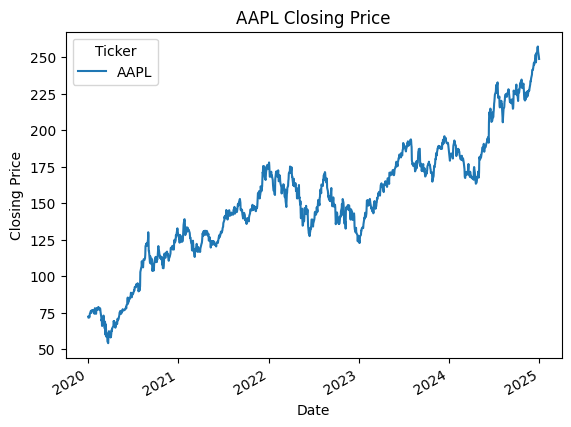

In [3]:
# Plot closing price for a ticker against date
data.plot(y = "Close")
plt.title("AAPL Closing Price")
plt.ylabel('Closing Price')
plt.xlabel('Date')

## Trial 1

In [4]:
import sys
from pathlib import Path
import matplotlib.pyplot

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import compute_returns, moving_average

In [5]:
df = get_data('AAPL', '2020-01-01', '2025-01-01')
df = compute_returns(df)
df = moving_average(df)

df.head(15)


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,returns,ma
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,-0.009722,NaN
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200,0.007968,NaN
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,-0.004703,NaN
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,0.016086,NaN
2020-01-09,74.568802,74.761465,73.742750,73.993210,170108400,0.021241,NaN
2020-01-10,74.737381,75.300934,74.236454,74.802410,140644800,0.002261,NaN
2020-01-13,76.334091,76.360587,74.934858,75.052871,121532000,0.021364,NaN
2020-01-14,75.303329,76.481001,75.180510,76.271479,161954400,-0.013503,NaN


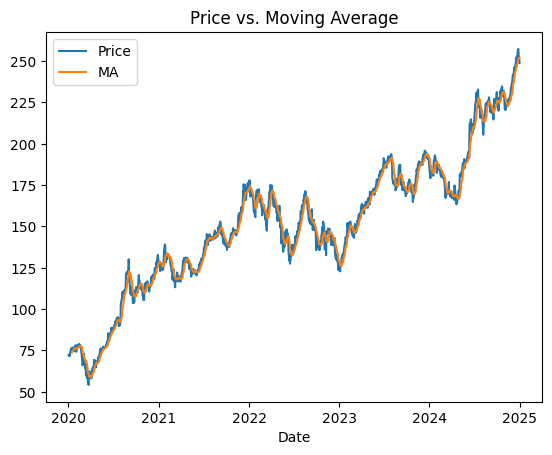

In [6]:
#Plotting Price against Moving Average
plt.plot(df.index, df[('Close', 'AAPL')], label='Price')
plt.plot(df.index, df['ma'], label='MA')

plt.title('Price vs. Moving Average')
plt.xlabel('Date')
plt.legend()
plt.show()

## Momentum Strategy

In [7]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import compute_returns, moving_average
from src.strategy import momentum_strategy
from src.backtest import backtest, sharpe_ratio


In [8]:
df = get_data('AAPL', '2020-01-01', '2025-01-01')
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


In [9]:
df = compute_returns(df)
df.head()

Price,Close,High,Low,Open,Volume,returns
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,-0.009722
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200,0.007968
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,-0.004703
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,0.016086


In [10]:
df = moving_average(df)
df.tail()

Price,Close,High,Low,Open,Volume,returns,ma
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
2024-12-24,256.560852,256.570768,253.669307,253.868050,23234700,0.011478,249.694691
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,0.003176,250.939732
2024-12-27,253.967377,257.057649,251.453440,256.193146,42355300,-0.013242,251.697888
2024-12-30,250.598923,251.890673,249.158131,250.628731,35557500,-0.013263,252.102304
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,-0.007058,252.040700


In [11]:
df["market_cumulative"] = (1 + df["returns"]).cumprod()

In [ ]:
df = momentum_strategy(df)
df.tail(15)

Price,Close,High,Low,Open,Volume,returns,ma,market_cumulative,momentum,signal
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
2024-12-03,241.109512,241.218815,237.383319,238.287546,38861000,0.012772,232.325655,3.333286,0.064161,1
2024-12-04,241.467255,242.560277,239.718433,241.328144,44383900,0.001484,233.789302,3.338232,0.064526,1
2024-12-05,241.497070,242.987548,240.592859,242.441051,40033900,0.000123,235.184389,3.338644,0.061310,1
2024-12-06,241.298325,243.076969,240.543155,241.367887,36870600,-0.000823,236.607298,3.335896,0.062664,1
2024-12-09,245.183517,245.670412,240.215260,240.294754,44649200,0.016101,238.284583,3.389608,0.073433,1
2024-12-10,246.197006,246.634215,243.782425,245.322588,36914800,0.004134,239.765123,3.403620,0.063984,1
2024-12-11,244.925171,249.207807,244.696620,246.385840,45205800,-0.005166,240.900868,3.386037,0.048626,1
2024-12-12,246.385818,247.160865,244.120279,245.322604,32777500,0.005964,242.195598,3.406230,0.055463,1
2024-12-13,246.554764,247.707388,244.676763,246.246734,33155300,0.000686,243.268742,3.408566,0.045506,1


In [13]:
df = backtest(df)
df.tail(10)

Price,Close,High,Low,Open,Volume,returns,ma,market_cumulative,momentum,signal,strategy_returns,cumulative_returns
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,
2024-12-17,251.870773,252.218557,248.194266,248.492364,51356400,0.009720,245.482596,3.482058,0.044632,1,0.009720,2.659896
2024-12-18,246.475266,252.665710,246.167236,250.559174,56774100,-0.021422,245.983397,3.407467,0.020740,1,-0.021422,2.602917
2024-12-19,248.204193,250.400170,245.521337,245.928738,60882300,0.007015,246.654109,3.431369,0.027773,1,0.007015,2.621175
2024-12-20,252.874390,253.381146,244.130253,246.465325,147495300,0.018816,247.811716,3.495933,0.047974,1,0.018816,2.670495
2024-12-23,253.649429,254.027007,251.840976,253.152604,40858800,0.003065,248.658307,3.506648,0.034529,1,0.003065,2.678680
2024-12-24,256.560852,256.570768,253.669307,253.868050,23234700,0.011478,249.694691,3.546898,0.042096,1,0.011478,2.709426
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,0.003176,250.939732,3.558161,0.050834,1,0.003176,2.718030
2024-12-27,253.967377,257.057649,251.453440,256.193146,42355300,-0.013242,251.697888,3.511043,0.030771,1,-0.013242,2.682038
2024-12-30,250.598923,251.890673,249.158131,250.628731,35557500,-0.013263,252.102304,3.464475,0.016403,1,-0.013263,2.646465


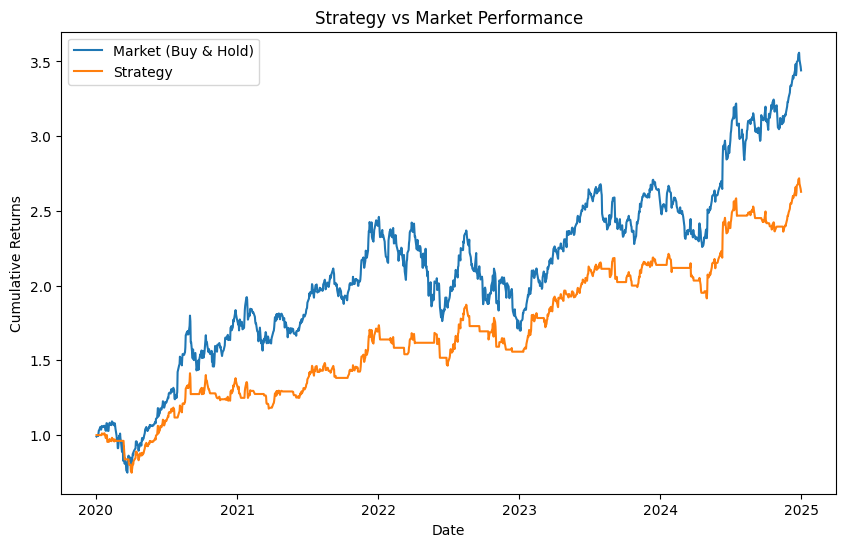

In [14]:
plt.figure(figsize=(10,6))
plt.plot(df.index, df["market_cumulative"], label="Market (Buy & Hold)")
plt.plot(df.index, df["cumulative_returns"], label="Strategy")

plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.title("Strategy vs Market Performance")
plt.legend()
plt.show()

In [20]:
print("Returns Sharpe Ratio: " + str(sharpe_ratio(df['returns'])))
print("Strategy Returns Sharpe Ratio: " + str(sharpe_ratio(df['strategy_returns'])))

Returns Sharpe Ratio: 0.940729958071248
Strategy Returns Sharpe Ratio: 1.0168937889326062


## Momentum Strategy, Window = 20

[*********************100%***********************]  1 of 1 completed


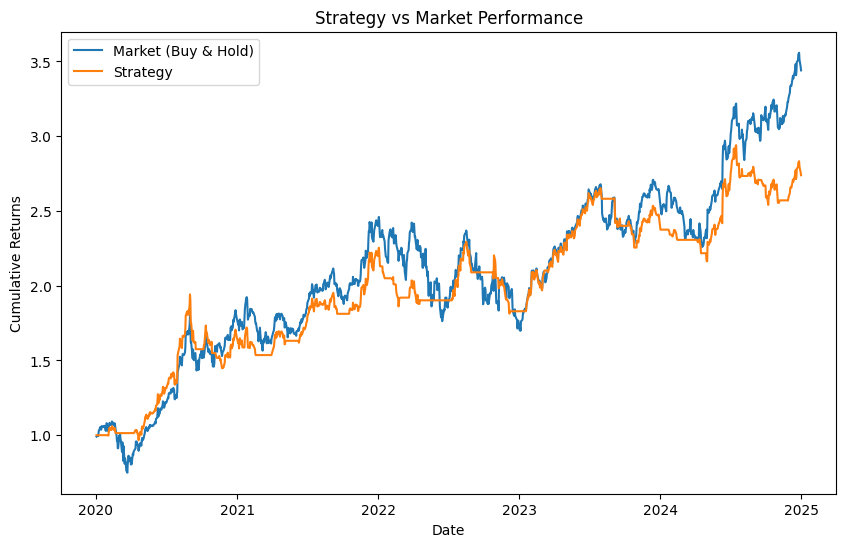

In [21]:
df = get_data('AAPL', '2020-01-01', '2025-01-01')
df = compute_returns(df)
df = moving_average(df, window = 20)
df["market_cumulative"] = (1 + df["returns"]).cumprod()
df = momentum_strategy(df, window = 20)
df = backtest(df)


plt.figure(figsize=(10,6))
plt.plot(df.index, df["market_cumulative"], label="Market (Buy & Hold)")
plt.plot(df.index, df["cumulative_returns"], label="Strategy")

plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.title("Strategy vs Market Performance")
plt.legend()
plt.show()

In [22]:
print("Returns Sharpe Ratio: " + str(sharpe_ratio(df['returns'])))
print("Strategy Returns Sharpe Ratio: " + str(sharpe_ratio(df['strategy_returns'])))

Returns Sharpe Ratio: 0.940729958071248
Strategy Returns Sharpe Ratio: 1.0789460845341445
